In [1]:
# Quick test: verify model imports and works without torch-geometric-temporal
import torch
from model import ComboModel, SimpleGraphGRU

# Create dummy data
T, N, F = 10, 5, 3  # 10 timesteps, 5 nodes, 3 features
x_test = torch.randn(T, N, F)

# Create a small test model
test_model = ComboModel(num_features=3, hidden_dim=16, heads=2, attn_layers=1, seq_len=T)

# Create dummy edge info (list of tuples)
edge_info_test = []
for t in range(T):
    # Simple fully connected graph
    edge_index = torch.tensor([[i, j] for i in range(N) for j in range(N) if i != j]).T
    edge_weight = torch.rand(edge_index.shape[1])
    edge_info_test.append((edge_index, edge_weight))

# Forward pass
with torch.no_grad():
    output = test_model(x_test, edge_info_test)

print(f"✓ Model test passed!")
print(f"  Input shape: {x_test.shape}")
print(f"  Output shape: {output.shape}")
print(f"  Expected: ({T}, {N}, 1)")
print(f"  Model parameters: {sum(p.numel() for p in test_model.parameters()):,}")
print("\n✓ Ready to train on your futures data!")

✓ Model test passed!
  Input shape: torch.Size([10, 5, 3])
  Output shape: torch.Size([10, 5, 1])
  Expected: (10, 5, 1)
  Model parameters: 6,049

✓ Ready to train on your futures data!


In [2]:
import asyncio
import datetime

In [3]:

""" # Initialize the client
client = HistoricInteractiveBrokersClient(
    host="127.0.0.1",
    port=4002,
    client_id=1,
    market_data_type=MarketDataTypeEnum.DELAYED_FROZEN,  # Use delayed data if no subscription
    log_level="INFO"
)

# Connect to TWS/Gateway
await client.connect() """

' # Initialize the client\nclient = HistoricInteractiveBrokersClient(\n    host="127.0.0.1",\n    port=4002,\n    client_id=1,\n    market_data_type=MarketDataTypeEnum.DELAYED_FROZEN,  # Use delayed data if no subscription\n    log_level="INFO"\n)\n\n# Connect to TWS/Gateway\nawait client.connect() '

In [4]:
""" # Define contracts
contracts = [
    IBContract(secType="STK", symbol="AAPL", exchange="SMART", primaryExchange="NASDAQ"),
    IBContract(secType="STK", symbol="MSFT", exchange="SMART", primaryExchange="NASDAQ"),
    IBContract(secType="CASH", symbol="EUR", currency="USD", exchange="IDEALPRO"),
]

# Request instrument definitions
instruments = await client.request_instruments(contracts=contracts)
instruments """

' # Define contracts\ncontracts = [\n    IBContract(secType="STK", symbol="AAPL", exchange="SMART", primaryExchange="NASDAQ"),\n    IBContract(secType="STK", symbol="MSFT", exchange="SMART", primaryExchange="NASDAQ"),\n    IBContract(secType="CASH", symbol="EUR", currency="USD", exchange="IDEALPRO"),\n]\n\n# Request instrument definitions\ninstruments = await client.request_instruments(contracts=contracts)\ninstruments '

In [5]:
""" 
# Request historical bars
bars = await client.request_bars(
    bar_specifications=[
        "1-MINUTE-LAST",    # 1-minute bars using last price
        "5-MINUTE-MID",     # 5-minute bars using midpoint
        "1-HOUR-LAST",      # 1-hour bars using last price
        "1-DAY-LAST",       # Daily bars using last price
    ],
    start_date_time=datetime.datetime(2023, 11, 1, 9, 30),
    end_date_time=datetime.datetime(2023, 11, 6, 16, 30),
    tz_name="America/New_York",
    contracts=contracts,
    use_rth=True,  # Regular Trading Hours only
    timeout=120,   # Request timeout in seconds
)


bars
 """

' \n# Request historical bars\nbars = await client.request_bars(\n    bar_specifications=[\n        "1-MINUTE-LAST",    # 1-minute bars using last price\n        "5-MINUTE-MID",     # 5-minute bars using midpoint\n        "1-HOUR-LAST",      # 1-hour bars using last price\n        "1-DAY-LAST",       # Daily bars using last price\n    ],\n    start_date_time=datetime.datetime(2023, 11, 1, 9, 30),\n    end_date_time=datetime.datetime(2023, 11, 6, 16, 30),\n    tz_name="America/New_York",\n    contracts=contracts,\n    use_rth=True,  # Regular Trading Hours only\n    timeout=120,   # Request timeout in seconds\n)\n\n\nbars\n '

In [6]:
import pandas as pd
from pathlib import Path
p = Path("data/futures")
parquet_files = sorted(p.glob("*.parquet"))

dfs = []
for pf in parquet_files:
    tmp = pd.read_parquet(pf)

    # Flatten MultiIndex columns if present
    if isinstance(tmp.columns, pd.MultiIndex):
        def _flatten(col):
            for part in col:
                if part and str(part).strip() != "":
                    return str(part)
            return "_".join([str(x) for x in col if x])
        tmp.columns = [_flatten(c) for c in tmp.columns]

    # Normalize timestamp column name to 'ts'
    ts_candidates = [c for c in tmp.columns if "timestamp" in c.lower() or c.lower() == "ts"]
    if ts_candidates:
        tmp = tmp.rename(columns={ts_candidates[0]: "ts"})

    # Ensure a ticker column (use filename stem if missing)
    if "ticker" not in tmp.columns:
        tmp["ticker"] = pf.stem

    tmp["ts"] = pd.to_datetime(tmp["ts"])
    dfs.append(tmp)

# Concatenate all files into a single DataFrame
df = pd.concat(dfs, ignore_index=True, sort=False)
df

,ts,close,high,low,open,volume,ticker
0,2000-09-12,0.873000,0.878000,0.873000,0.878000,94,6E
1,2000-09-13,0.877100,0.877100,0.875000,0.876500,80,6E
2,2000-09-15,0.871500,0.871500,0.871500,0.871500,110,6E
3,2000-09-18,0.867500,0.871500,0.867500,0.871500,110,6E
4,2000-09-19,0.866500,0.869300,0.863500,0.871500,110,6E
...,...,...,...,...,...,...,...
69506,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN
69507,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN
69508,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN
69509,2025-12-17,112.671875,112.703125,112.421875,112.687500,1340,ZN


In [7]:
# earliest timestamp for each ticker
earliest_per_ticker = (
    df.groupby("ticker", observed=True)["ts"]
      .min()
      .reset_index()
      .rename(columns={"ts": "earliest_ts"})
      .sort_values("earliest_ts")
)
earliest_per_ticker

,ticker,earliest_ts
2,CL,2000-08-23
4,GC,2000-08-30
5,NG,2000-08-30
7,SI,2000-08-30
0,6E,2000-09-12
1,6J,2000-09-13
3,ES,2000-09-18
6,NQ,2000-09-18
9,ZB,2000-09-21
10,ZN,2000-09-21


In [8]:
# remove rows with timestamps before 2002-04-05
import datetime
cutoff = datetime.datetime(2002, 4, 5)
df = df[df["ts"] >= cutoff].reset_index(drop=True)
df

,ts,close,high,low,open,volume,ticker
0,2002-04-05,0.876700,0.878900,0.874800,0.875500,0,6E
1,2002-04-08,0.871600,0.876900,0.871100,0.876700,0,6E
2,2002-04-09,0.878100,0.878500,0.871200,0.872100,0,6E
3,2002-04-10,0.878000,0.880000,0.876400,0.878500,0,6E
4,2002-04-11,0.880700,0.882300,0.876800,0.878000,0,6E
...,...,...,...,...,...,...,...
65679,2025-12-12,112.343750,112.593750,112.281250,112.593750,761,ZN
65680,2025-12-15,112.453125,112.609375,112.453125,112.609375,2017,ZN
65681,2025-12-16,112.687500,112.687500,112.203125,112.562500,1340,ZN
65682,2025-12-17,112.671875,112.703125,112.421875,112.687500,1340,ZN


In [9]:
# Chronological 80/20 split per ticker (train gets first 80% of each ticker's history)
train_parts = []
test_parts = []

for _, g in df.groupby("ticker", sort=False, observed=True):
    g = g.sort_values("ts")
    n = len(g)
    k = max(1, int(n * 0.8))  # ensure at least one row in train for non-empty groups
    train_parts.append(g.iloc[:k])
    test_parts.append(g.iloc[k:])

train_df = pd.concat(train_parts, ignore_index=True, sort=False).sort_values(["ticker", "ts"]).reset_index(drop=True)
test_df = pd.concat(test_parts, ignore_index=True, sort=False).sort_values(["ticker", "ts"]).reset_index(drop=True)

# Sanity checks
assert len(train_df) + len(test_df) == len(df)
# no overlap
# no overlap based on (ticker, ts) keys
overlap = pd.merge(
    train_df[['ticker', 'ts']],
    test_df[['ticker', 'ts']],
    on=['ticker', 'ts'],
    how='inner'
)
assert overlap.empty, f"Found {len(overlap)} overlapping rows between train and test"

print(f"Total rows: {len(df)}, Train: {len(train_df)}, Test: {len(test_df)}")
print("Train counts per ticker:\n", train_df["ticker"].value_counts().sort_index())
print("Test counts per ticker:\n", test_df["ticker"].value_counts().sort_index())

Total rows: 65684, Train: 52541, Test: 13143
Train counts per ticker:
 ticker
6E    4792
6J    4793
CL    4767
ES    4792
GC    4764
NG    4768
NQ    4792
SI    4764
YM    4775
ZB    4769
ZN    4765
Name: count, dtype: int64
Test counts per ticker:
 ticker
6E    1199
6J    1199
CL    1192
ES    1199
GC    1191
NG    1193
NQ    1199
SI    1192
YM    1194
ZB    1193
ZN    1192
Name: count, dtype: int64


In [10]:
def add_prev_close(df):
    # ensure chronological order per ticker
    df = df.sort_values(["ticker", "ts"]).reset_index(drop=True)

    # calculate 1-period log returns per ticker
    df["prev_close"] = df.groupby("ticker")["close"].shift(1)

    # show result
    df[df["ticker"]=="ES"]
    return df

train_df = add_prev_close(train_df)
test_df = add_prev_close(test_df)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def add_log_returns(df):
    df["log_returns"] = np.log(df["close"] / df["prev_close"])
    # plt.hist(df[df["ticker"] == "ES"]["log_returns"], bins=55)
    return df

train_df = add_log_returns(train_df)
test_df = add_log_returns(test_df)

/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
def add_30_day_std(df):
    df["30day_std"] = df.groupby("ticker")["log_returns"].transform(lambda x: x.rolling(30, min_periods=20).std())
    return df

train_df = add_30_day_std(train_df)
test_df = add_30_day_std(test_df)

In [13]:
def add_momentum(df):
    df["21day_momentum"] = df.groupby("ticker")["log_returns"].transform(lambda x: x - x.shift(21))
    df["63day_momentum"] = df.groupby("ticker")["log_returns"].transform(lambda x: x - x.shift(63))
    return df

train_df = add_momentum(train_df)
test_df = add_momentum(test_df)

In [14]:
def add_rsi(df):
    # 14-period RSI (Wilder smoothing) per ticker
    RSI_PERIOD = 14

    def _rsi(close_series, period=RSI_PERIOD):
        delta = close_series.diff()
        up = delta.clip(lower=0)
        down = -delta.clip(upper=0)
        # Wilder's smoothing via ewm with alpha=1/period
        avg_up = up.ewm(alpha=1/period, adjust=False).mean()
        avg_down = down.ewm(alpha=1/period, adjust=False).mean()
        rs = avg_up / avg_down
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df["rsi_14"] = df.groupby("ticker")["close"].apply(_rsi).reset_index(level=0, drop=True)

    return df

train_df = add_rsi(train_df)
test_df = add_rsi(test_df)

In [15]:
def add_bollinger_ema(df):
    # 21-day Bollinger Bands using EMA per ticker
    EMA_WINDOW = 21
    MIN_PERIODS = 5

    def _ew_std(s, span):
        ema = s.ewm(span=span, adjust=False).mean()
        ewvar = ((s - ema) ** 2).ewm(span=span, adjust=False).mean()
        return np.sqrt(ewvar)

    # EMA mid and EW std per ticker
    df["bb_mid_ema"] = df.groupby("ticker")["close"].transform(lambda x: x.ewm(span=EMA_WINDOW, adjust=False).mean())
    df["bb_std_ema"] = df.groupby("ticker")["close"].transform(lambda x: _ew_std(x, EMA_WINDOW))

    # bands and %b
    df["bb_upper_ema"] = df["bb_mid_ema"] + 2 * df["bb_std_ema"]
    df["bb_lower_ema"] = df["bb_mid_ema"] - 2 * df["bb_std_ema"]
    df["bb_pct_b_ema"] = (df["close"] - df["bb_lower_ema"]) / (df["bb_upper_ema"] - df["bb_lower_ema"])

    # guard against invalid ranges
    df.loc[df["bb_upper_ema"] <= df["bb_lower_ema"], "bb_pct_b_ema"] = pd.NA

    # enforce MIN_PERIODS before exposing values
    df["_cnt"] = df.groupby("ticker").cumcount() + 1
    df.loc[df["_cnt"] < MIN_PERIODS, ["bb_mid_ema", "bb_std_ema", "bb_upper_ema", "bb_lower_ema", "bb_pct_b_ema"]] = pd.NA
    df.drop(columns="_cnt", inplace=True)
    
    return df

train_df = add_bollinger_ema(train_df)
test_df = add_bollinger_ema(test_df)

In [16]:
def add_amihud(df):
    WINDOW = 21
    MIN_PERIODS = 5

    # dollar volume: use close * volume (if your volume is already in USD, set dollar_volume = df["volume"])
    df["dollar_volume"] = df["close"] * df["volume"]

    # daily Amihud (guard against division by zero / infinities)
    df["amihud_daily"] = (df["log_returns"].abs() / df["dollar_volume"]).replace([np.inf, -np.inf], pd.NA)
    
    return df

train_df = add_amihud(train_df)
test_df = add_amihud(test_df)

In [17]:
def amihud_fragility(df):
    FRAG_WINDOW = 14
    MIN_PERIODS = 5

    # ensure amihud_daily is numeric
    df["amihud_daily"] = pd.to_numeric(df["amihud_daily"], errors="coerce")

    group = df.groupby("ticker")["amihud_daily"]
    rolling_std = group.transform(lambda x: x.rolling(FRAG_WINDOW, min_periods=MIN_PERIODS).std())
    rolling_mean = group.transform(lambda x: x.rolling(FRAG_WINDOW, min_periods=MIN_PERIODS).mean())

    # fragility = rolling std / rolling mean, guard against zero / inf
    df["amihud_fragility"] = (rolling_std / rolling_mean).replace([np.inf, -np.inf], pd.NA)
    df.loc[rolling_mean == 0, "amihud_fragility"] = pd.NA

    return df

train_df = amihud_fragility(train_df)
test_df = amihud_fragility(test_df)

In [18]:
# cell 16 -- clean NaNs in train_df and test_df
def clean_nans(df, critical_cols=None):
    df = df.copy()
    if critical_cols is None:
        critical_cols = [
            "prev_close", "log_returns", "30day_std",
            "bb_mid_ema", "bb_std_ema", "bb_pct_b_ema",
            "rsi_14", "amihud_daily", "amihud_fragility",
        ]

    # summary before
    print("rows:", len(df))
    print("NaNs per column (before):")
    print(df.isna().sum())

    # drop rows missing any critical features (ensures model-ready rows)
    df = df.dropna(subset=critical_cols).reset_index(drop=True)

    # forward/backward fill remaining numeric columns within each ticker
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    # transform keeps index alignment
    df[num_cols] = df.groupby("ticker")[num_cols].transform(lambda g: g.ffill().bfill())

    # fill any remaining numeric NaNs with column median (global)
    for c in df.select_dtypes(include=["number"]).columns:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())

    # final summary
    print("\nrows (after):", len(df))
    print("NaNs per column (after):")
    print(df.isna().sum())

    # show per-ticker counts to detect heavy dropping
    print("\nrows per ticker (after):")
    print(df["ticker"].value_counts().sort_index())

    return df

train_df = clean_nans(train_df)
test_df = clean_nans(test_df)

rows: 52541
NaNs per column (before):
ts                     0
close                  0
high                   0
low                    0
open                   0
volume                 0
ticker                 0
prev_close            11
log_returns           13
30day_std            220
21day_momentum       246
63day_momentum       708
rsi_14                11
bb_mid_ema            44
bb_std_ema            44
bb_upper_ema          44
bb_lower_ema          44
bb_pct_b_ema          44
dollar_volume          0
amihud_daily        1978
amihud_fragility    1440
dtype: int64

rows (after): 50345
NaNs per column (after):
ts                  0
close               0
high                0
low                 0
open                0
volume              0
ticker              0
prev_close          0
log_returns         0
30day_std           0
21day_momentum      0
63day_momentum      0
rsi_14              0
bb_mid_ema          0
bb_std_ema          0
bb_upper_ema        0
bb_lower_ema        0
bb_p

In [19]:
from statsmodels.tsa.stattools import coint

# compute pairwise Engle–Granger cointegration (uses the full history up to the final timestamp)

# pivot closes into wide table aligned by timestamp
price_wide = df.pivot(index="ts", columns="ticker", values="close").sort_index()
tickers = price_wide.columns.tolist()

# prepare result containers
pval_matrix = pd.DataFrame(np.nan, index=tickers, columns=tickers)
tstat_matrix = pd.DataFrame(np.nan, index=tickers, columns=tickers)

# pairwise cointegration tests (only test on overlapping timestamps)
MIN_OBS = 50  # require at least this many overlapping observations
for i, a in enumerate(tickers):
    for j in range(i + 1, len(tickers)):
        b = tickers[j]
        s1 = price_wide[a].dropna()
        s2 = price_wide[b].dropna()
        common = s1.index.intersection(s2.index)
        if len(common) < MIN_OBS:
            continue
        x = s1.loc[common]
        y = s2.loc[common]
        try:
            tstat, pvalue, _ = coint(x, y)
            pval_matrix.at[a, b] = pvalue
            pval_matrix.at[b, a] = pvalue
            tstat_matrix.at[a, b] = tstat
            tstat_matrix.at[b, a] = tstat
        except Exception:
            # skip pairs that fail for numerical reasons
            continue

# boolean cointegration mask at 5% significance
cointegrated_mask = pval_matrix < 0.05

# expose results to notebook
cointegration_pvals = pval_matrix
cointegration_tstats = tstat_matrix
cointegrated_pairs = cointegrated_mask

print("Pairwise cointegration p-values (NaN = insufficient overlap / test failed):")
print(cointegration_pvals)
print("\nPairs considered cointegrated at alpha=0.05:")
cointegrated_pairs

Pairwise cointegration p-values (NaN = insufficient overlap / test failed):
          6E        6J        CL        ES        GC        NG        NQ  \
6E       NaN  0.106689  0.139514  0.041176  0.093949  0.088911  0.054275   
6J  0.106689       NaN  0.814925  0.372243  0.628944  0.908855  0.412487   
CL  0.139514  0.814925       NaN  0.095925  0.140050  0.089188  0.092616   
ES  0.041176  0.372243  0.095925       NaN  0.687995  0.986672  0.258819   
GC  0.093949  0.628944  0.140050  0.687995       NaN  0.993508  0.907661   
NG  0.088911  0.908855  0.089188  0.986672  0.993508       NaN  0.087366   
NQ  0.054275  0.412487  0.092616  0.258819  0.907661  0.087366       NaN   
SI  0.266949  0.972129  0.378091  0.782939  0.214140  0.084163  0.754996   
YM  0.030190  0.399450  0.097187  0.722372  0.980840  0.073741  0.457709   
ZB  0.077630  0.922345  0.089180  1.000000  1.000000  0.007130  1.000000   
ZN  0.178747  0.907702  0.079404  1.000000  1.000000  0.018684  1.000000   

          S

,6E,6J,CL,ES,GC,NG,NQ,SI,YM,ZB,ZN
6E,False,False,False,True,False,False,False,False,True,False,False
6J,False,False,False,False,False,False,False,False,False,False,False
CL,False,False,False,False,False,False,False,False,False,False,False
ES,True,False,False,False,False,False,False,False,False,False,False
GC,False,False,False,False,False,False,False,False,False,False,False
NG,False,False,False,False,False,False,False,False,False,True,True
NQ,False,False,False,False,False,False,False,False,False,False,False
SI,False,False,False,False,False,False,False,False,False,False,False
YM,True,False,False,False,False,False,False,False,False,False,False
ZB,False,False,False,False,False,True,False,False,False,False,False


In [20]:
# compute log returns from the wide price table and get the cross-sectional correlation
log_returns = np.log(price_wide / price_wide.shift(1))
log_returns = log_returns.dropna(how="all")  # remove leading all-NaN row(s)

corr_matrix = log_returns.corr()

print("Final timestamp used:", price_wide.index.max())
corr_matrix
log_returns = np.log(price_wide / price_wide.shift(1))
log_returns = log_returns.dropna(how="all")  # remove leading all-NaN row(s)

corr_matrix = log_returns.corr()

print("Final timestamp used:", price_wide.index.max())
corr_matrix#
corr_matrix = log_returns.corr()

log_returns = log_returns.dropna(how="all")  # remove leading all-NaN row(s)
log_returns = np.log(price_wide / price_wide.shift(1)) # compute log returns from the wide price table and get the cross-sectional correlation

Final timestamp used: 2025-12-18 00:00:00
Final timestamp used: 2025-12-18 00:00:00


/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/williserdman/Documents/Projects/q_explorer/ibkr/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [21]:
# compute rolling pairwise correlations (one correlation matrix per timestamp),
# then compute an EMA-smoothed correlation for each pair over time.
# Uses existing `log_returns` (wide DataFrame, index=ts, columns=tickers) and `tickers`.

window = 63
min_periods = max(5, int(window // 2))
ema_span = 21  # span for EMA smoothing of correlations

pairs = [(a, b) for a in tickers for b in tickers]

# build DataFrame of pairwise rolling correlations: index = timestamps, columns = MultiIndex (i, j)
rolling_corr_df = pd.DataFrame(index=log_returns.index)

for a, b in pairs:
    rolling_corr_df[(a, b)] = log_returns[a].rolling(window=window, min_periods=min_periods).corr(log_returns[b])

rolling_corr_df.columns = pd.MultiIndex.from_tuples(rolling_corr_df.columns, names=["i", "j"])

# EMA smoothing applied independently to each (i,j) correlation time series
ema_corr_df = rolling_corr_df.ewm(span=ema_span, adjust=False).mean()

# helper accessors: return a square correlation matrix (DataFrame) at a timestamp
def corr_matrix_at(ts, corr_df=rolling_corr_df):
    row = corr_df.loc[ts]
    return row.unstack(level=1)  # rows = i, cols = j

def ema_corr_matrix_at(ts, corr_df=ema_corr_df):
    row = corr_df.loc[ts]
    return row.unstack(level=1)

# examples: show latest timestamp matrices
latest_ts = rolling_corr_df.index.max()
print("Latest timestamp:", latest_ts)
corr_latest = corr_matrix_at(latest_ts)
ema_corr_latest = ema_corr_matrix_at(latest_ts)

ema_corr_latest

Latest timestamp: 2025-12-18 00:00:00


/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_39297/4167155239.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rolling_corr_df[(a, b)] = log_returns[a].rolling(window=window, min_periods=min_periods).corr(log_returns[b])
/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_39297/4167155239.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rolling_corr_df[(a, b)] = log_returns[a].rolling(window=window, min_periods=min_periods).corr(log_returns[b])
/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykern

j,6E,6J,CL,ES,GC,NG,NQ,SI,YM,ZB,ZN
i,,,,,,,,,,,
6E,1.000000,0.669533,-0.078361,0.060319,0.281932,-0.111734,-0.008805,0.271087,0.139749,0.334247,0.420069
6J,0.669533,1.000000,-0.263232,0.012789,0.146391,-0.020574,-0.058333,0.129010,0.079349,0.384383,0.479370
CL,-0.078361,-0.263232,1.000000,0.164635,-0.021456,0.040553,0.162751,0.005787,0.001094,-0.366780,-0.359317
ES,0.060319,0.012789,0.164635,1.000000,0.218147,0.050231,0.960371,0.220331,0.837309,-0.171993,-0.175736
GC,0.281932,0.146391,-0.021456,0.218147,1.000000,0.049061,0.200511,0.823008,0.201710,0.029251,0.058308
NG,-0.111734,-0.020574,0.040553,0.050231,0.049061,1.000000,0.027252,-0.043591,0.085758,0.049197,0.047440
NQ,-0.008805,-0.058333,0.162751,0.960371,0.200511,0.027252,1.000000,0.217671,0.709738,-0.195137,-0.240153
SI,0.271087,0.129010,0.005787,0.220331,0.823008,-0.043591,0.217671,1.000000,0.224669,-0.032600,-0.030254
YM,0.139749,0.079349,0.001094,0.837309,0.201710,0.085758,0.709738,0.224669,1.000000,-0.043690,-0.021968


In [22]:
import torch
import numpy as np

# Settings
corr_source = ema_corr_df          # use EMA-smoothed correlations from cell 19
feat_source_idx = log_returns.index  # timestamps aligned with rolling/ema correlation
node_order = tickers               # tickers list from cell 17
min_abs_corr = 0.0                 # keep all non-NaN correlations (set >0 to threshold)
undirected = True                  # create both (i->j) and (j->i) edges
device = torch.device("cpu")

# helper: convert square DataFrame (index=cols=node labels) -> edge_index, edge_weight tensors
def corr_matrix_to_edge_index(mat: pd.DataFrame, min_abs: float = 0.0, undirected: bool = True):
    # mat: square DataFrame with rows/cols matching node_order
    # returns: edge_index (2, E) long tensor, edge_weight (E,) float tensor
    assert list(mat.index) == list(mat.columns), "corr matrix must be square with same index/columns"
    n = len(mat.columns)
    name_to_idx = {name: i for i, name in enumerate(mat.columns)}
    rows, cols, weights = [], [], []
    arr = mat.values
    # iterate upper triangle (including diagonal if you want self-loops)
    iu = np.triu_indices(n, k=0)  # change k=1 to exclude self loops
    for r, c in zip(iu[0], iu[1]):
        w = arr[r, c]
        if np.isnan(w):
            continue
        if abs(w) < min_abs:
            continue
        # add edge r->c
        rows.append(r)
        cols.append(c)
        weights.append(float(w))
        if undirected and r != c:
            rows.append(c)
            cols.append(r)
            weights.append(float(w))
    if len(rows) == 0:
        # empty graph fallback: no edges
        edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
        edge_weight = torch.empty((0,), dtype=torch.float32, device=device)
    else:
        edge_index = torch.tensor([rows, cols], dtype=torch.long, device=device)
        edge_weight = torch.tensor(weights, dtype=torch.float32, device=device)
    return edge_index, edge_weight

# Build node features per timestamp
# features used: log_return, rolling vol (63), 21-step momentum (log_return - lag21)
vol_window = 63
mom_lag = 21

lr = log_returns.reindex(feat_source_idx)  # ensure same index ordering
vol = lr.rolling(window=vol_window, min_periods=5).std()
mom21 = lr - lr.shift(mom_lag)

# choose the timestamps that exist in corr_source (ema_corr_df) and in features
common_index = corr_source.index.intersection(lr.index).sort_values()
T = len(common_index)
N = len(node_order)
feature_dfs = [lr, vol, mom21]
F = len(feature_dfs)

# assemble X: shape (T, N, F)
X = np.zeros((T, N, F), dtype=np.float32)
for ti, ts in enumerate(common_index):
    for fi, df_feat in enumerate(feature_dfs):
        row = df_feat.loc[ts].reindex(node_order).values.astype(np.float32)  # (N,)
        # fill NaN with 0 (alternatively ffill/bfill can be applied)
        row = np.nan_to_num(row, nan=0.0, posinf=0.0, neginf=0.0)
        X[ti, :, fi] = row

# build target y: next-step log_return (shift -1). shape (T, N, 1)
# last timestamp will have no target -> set to 0 or drop in training
lr_common = lr.reindex(common_index)
y = lr_common.shift(-1).fillna(0.0).values.astype(np.float32)  # (T, N)
y = y.reshape(T, N, 1)

# build per-timestep edge_info list (edge_index, edge_weight)
edge_info = []
for ts in common_index:
    corr_mat = corr_source.loc[ts]
    # corr_mat could be a Series if corr_source had MultiIndex columns; ensure square DataFrame
    if isinstance(corr_mat, pd.Series):
        # attempt to reshape into square matrix using helper
        corr_square = ema_corr_matrix_at(ts)
    else:
        corr_square = corr_mat
    # ensure ordering matches node_order
    corr_square = corr_square.reindex(index=node_order, columns=node_order)
    eidx, ew = corr_matrix_to_edge_index(corr_square, min_abs=min_abs_corr, undirected=undirected)
    edge_info.append((eidx, ew))

# convert X and y to torch tensors
x_tensor = torch.from_numpy(X).to(dtype=torch.float32, device=device)      # (T, N, F)
y_tensor = torch.from_numpy(y).to(dtype=torch.float32, device=device)      # (T, N, 1)

# Example shapes and a sample edge
print("x_tensor.shape (T,N,F):", x_tensor.shape)
print("y_tensor.shape (T,N,1):", y_tensor.shape)
print("num timesteps:", T, "num nodes:", N, "num features:", F)
print("sample edge count at t=0:", edge_info[0][0].shape[1] if edge_info and edge_info[0][0].numel() else 0)
# edge_info is a list of (edge_index, edge_weight) aligned with common_index

# ready to feed into your model:
# model(x_tensor, edge_info)  # if your forward uses edge_info as second arg for graph edges

x_tensor.shape (T,N,F): torch.Size([5993, 11, 3])
y_tensor.shape (T,N,1): torch.Size([5993, 11, 1])
num timesteps: 5993 num nodes: 11 num features: 3
sample edge count at t=0: 0


In [23]:
# Train/Validation split (80/20 chronological split)
split_idx = int(len(common_index) * 0.8)

train_x = x_tensor[:split_idx]
train_y = y_tensor[:split_idx]
train_edges = edge_info[:split_idx]

val_x = x_tensor[split_idx:]
val_y = y_tensor[split_idx:]
val_edges = edge_info[split_idx:]

print(f"Train: {train_x.shape[0]} timesteps, Val: {val_x.shape[0]} timesteps")
print(f"Train date range: {common_index[0]} to {common_index[split_idx-1]}")
print(f"Val date range: {common_index[split_idx]} to {common_index[-1]}")

Train: 4794 timesteps, Val: 1199 timesteps
Train date range: 2002-04-05 00:00:00 to 2021-03-17 00:00:00
Val date range: 2021-03-18 00:00:00 to 2025-12-18 00:00:00


In [24]:
# Create dataloaders for training
from model import create_dataloader, ComboModel, train_model

# hyperparameters
SEQUENCE_LENGTH = 128   # number of timesteps per training sequence
BATCH_SIZE = 16        # batch size for training
STRIDE = 1             # stride for sliding window (1 = use all sequences)

train_loader = create_dataloader(
    train_x, train_y, train_edges,
    sequence_length=SEQUENCE_LENGTH,
    batch_size=BATCH_SIZE,
    stride=STRIDE,
    shuffle=True
)

val_loader = create_dataloader(
    val_x, val_y, val_edges,
    sequence_length=SEQUENCE_LENGTH,
    batch_size=BATCH_SIZE,
    stride=STRIDE,
    shuffle=False  # don't shuffle validation
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 292, Val batches: 67


In [25]:
# Initialize model
NUM_FEATURES = F  # from cell 20 (log_returns, vol, momentum)
HIDDEN_DIM = 32
HEADS = 4
ATTN_LAYERS = 2

model = ComboModel(
    num_features=NUM_FEATURES,
    hidden_dim=HIDDEN_DIM,
    heads=HEADS,
    attn_layers=ATTN_LAYERS,
    seq_len=SEQUENCE_LENGTH
)

print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Input features: {NUM_FEATURES}")
print(f"Hidden dimension: {HIDDEN_DIM}")
print(f"Attention heads: {HEADS}")
print(f"Attention layers: {ATTN_LAYERS}")

Model created with 38,849 parameters
Input features: 3
Hidden dimension: 32
Attention heads: 4
Attention layers: 2


In [26]:
# Train the model
results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=100,
    learning_rate=4e-6,
    weight_decay=1e-5,
    device=device,
    checkpoint_dir='checkpoints',
    patience=5,
    clip_grad=1.0,
    verbose=True
)

trained_model = results['model']
history = results['history']
best_epoch = results['best_epoch']

print(f"\nTraining complete! Best epoch: {best_epoch + 1}")

Training on device: cpu
Model parameters: 38,849
Training samples: 4667, Validation samples: 1072
--------------------------------------------------------------------------------
✓ New best model saved at epoch 1
Epoch   1/100 | Train Loss: 0.100770 | Val Loss: 0.008315 | Val MAE: 0.070263 | Val DirAcc: 0.499 | LR: 4.00e-06
✓ New best model saved at epoch 2
Epoch   2/100 | Train Loss: 0.089738 | Val Loss: 0.003827 | Val MAE: 0.047553 | Val DirAcc: 0.503 | LR: 4.00e-06
✓ New best model saved at epoch 3
Epoch   3/100 | Train Loss: 0.084122 | Val Loss: 0.002577 | Val MAE: 0.040025 | Val DirAcc: 0.504 | LR: 4.00e-06
✓ New best model saved at epoch 4
Epoch   4/100 | Train Loss: 0.080501 | Val Loss: 0.002104 | Val MAE: 0.036805 | Val DirAcc: 0.505 | LR: 4.00e-06
✓ New best model saved at epoch 5
Epoch   5/100 | Train Loss: 0.078009 | Val Loss: 0.001872 | Val MAE: 0.034878 | Val DirAcc: 0.506 | LR: 4.00e-06
✓ New best model saved at epoch 6
Epoch   6/100 | Train Loss: 0.076197 | Val Loss: 0.0

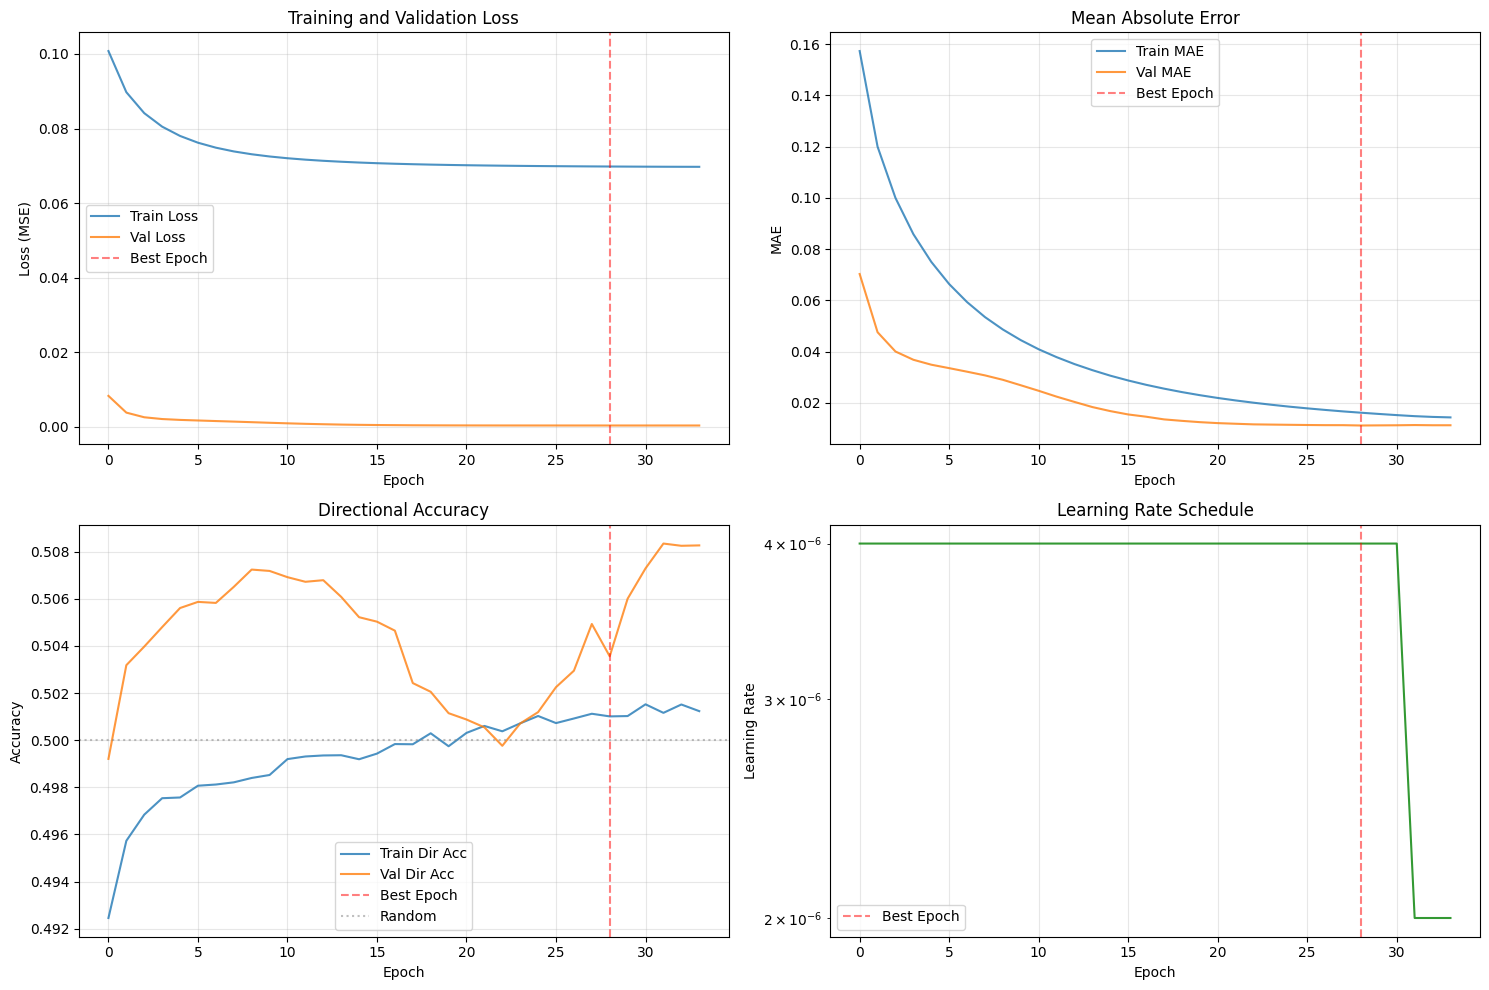

In [27]:
# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', alpha=0.8)
axes[0, 0].plot(history['val_loss'], label='Val Loss', alpha=0.8)
axes[0, 0].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label='Best Epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE
axes[0, 1].plot(history['train_mae'], label='Train MAE', alpha=0.8)
axes[0, 1].plot(history['val_mae'], label='Val MAE', alpha=0.8)
axes[0, 1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label='Best Epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Mean Absolute Error')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Directional Accuracy
axes[1, 0].plot(history['train_dir_acc'], label='Train Dir Acc', alpha=0.8)
axes[1, 0].plot(history['val_dir_acc'], label='Val Dir Acc', alpha=0.8)
axes[1, 0].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label='Best Epoch')
axes[1, 0].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Random')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Directional Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(history['learning_rates'], alpha=0.8, color='green')
axes[1, 1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label='Best Epoch')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Evaluate model on validation set with detailed per-ticker analysis
from model import validate_epoch
import torch.nn as nn

trained_model.eval()
val_predictions = []
val_targets = []

with torch.no_grad():
    for x_batch, y_batch, edges_batch in val_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        edges_batch_device = []
        for edges_seq in edges_batch:
            edges_seq_device = [(ei.to(device), ew.to(device)) for ei, ew in edges_seq]
            edges_batch_device.append(edges_seq_device)
        
        preds = trained_model(x_batch, edges_batch_device)
        val_predictions.append(preds[:, :-1].cpu())
        val_targets.append(y_batch[:, :-1].cpu())

val_predictions = torch.cat(val_predictions, dim=0)  # (num_samples, T-1, N, 1)
val_targets = torch.cat(val_targets, dim=0)

# Overall metrics
from model import compute_metrics
overall_metrics = compute_metrics(val_predictions, val_targets)

print("Validation Set Performance:")
print(f"  MSE:  {overall_metrics['mse']:.6f}")
print(f"  RMSE: {overall_metrics['rmse']:.6f}")
print(f"  MAE:  {overall_metrics['mae']:.6f}")
print(f"  Directional Accuracy: {overall_metrics['dir_acc']:.4f}")

# Per-ticker analysis
print("\n" + "="*80)
print("Per-Ticker Validation Performance:")
print("="*80)

# reshape to analyze by node (ticker)
# val_predictions: (B, T-1, N, 1) -> flatten to (B*(T-1), N, 1)
B, T_minus_1, N_nodes, _ = val_predictions.shape
flat_preds = val_predictions.reshape(-1, N_nodes, 1)  # (B*(T-1), N, 1)
flat_targets = val_targets.reshape(-1, N_nodes, 1)

for i, ticker in enumerate(tickers):
    ticker_preds = flat_preds[:, i, :]  # (B*(T-1), 1)
    ticker_targets = flat_targets[:, i, :]
    
    ticker_metrics = compute_metrics(ticker_preds, ticker_targets)
    print(f"{ticker:6s} | MSE: {ticker_metrics['mse']:.6f} | "
          f"MAE: {ticker_metrics['mae']:.6f} | "
          f"Dir Acc: {ticker_metrics['dir_acc']:.4f}")

Validation Set Performance:
  MSE:  0.000372
  RMSE: 0.019281
  MAE:  0.011155
  Directional Accuracy: 0.5036

Per-Ticker Validation Performance:
6E     | MSE: 0.000035 | MAE: 0.004656 | Dir Acc: 0.4987
6J     | MSE: 0.000056 | MAE: 0.005744 | Dir Acc: 0.4601
CL     | MSE: 0.000549 | MAE: 0.017644 | Dir Acc: 0.5126
ES     | MSE: 0.000135 | MAE: 0.008348 | Dir Acc: 0.5252
GC     | MSE: 0.000099 | MAE: 0.007393 | Dir Acc: 0.5237
NG     | MSE: 0.002465 | MAE: 0.037033 | Dir Acc: 0.5009
NQ     | MSE: 0.000222 | MAE: 0.010767 | Dir Acc: 0.5045
SI     | MSE: 0.000345 | MAE: 0.013793 | Dir Acc: 0.5150
YM     | MSE: 0.000097 | MAE: 0.007104 | Dir Acc: 0.5108
ZB     | MSE: 0.000061 | MAE: 0.006155 | Dir Acc: 0.5036
ZN     | MSE: 0.000027 | MAE: 0.004066 | Dir Acc: 0.4840


Decile long-short strategy summary (signal = predicted 1-step ahead):
horizon_days                1            3            5            10
observations       1199.000000  1197.000000  1195.000000  1190.000000
mean_period_ret       0.000221     0.001048     0.000617     0.000046
std_period_ret        0.028015     0.040893     0.055419     0.080327
ann_sharpe            0.125466     0.234864     0.079062     0.002848
cum_return           -0.227669     0.284650    -0.681509    -0.981884
ann_return_approx    -0.052849     0.017733    -0.047110    -0.081431
ann_vol_approx        0.444730     0.374788     0.393434     0.403238
avg_long              0.000361     0.001795     0.002824     0.004672
avg_short             0.000140     0.000747     0.002207     0.004627


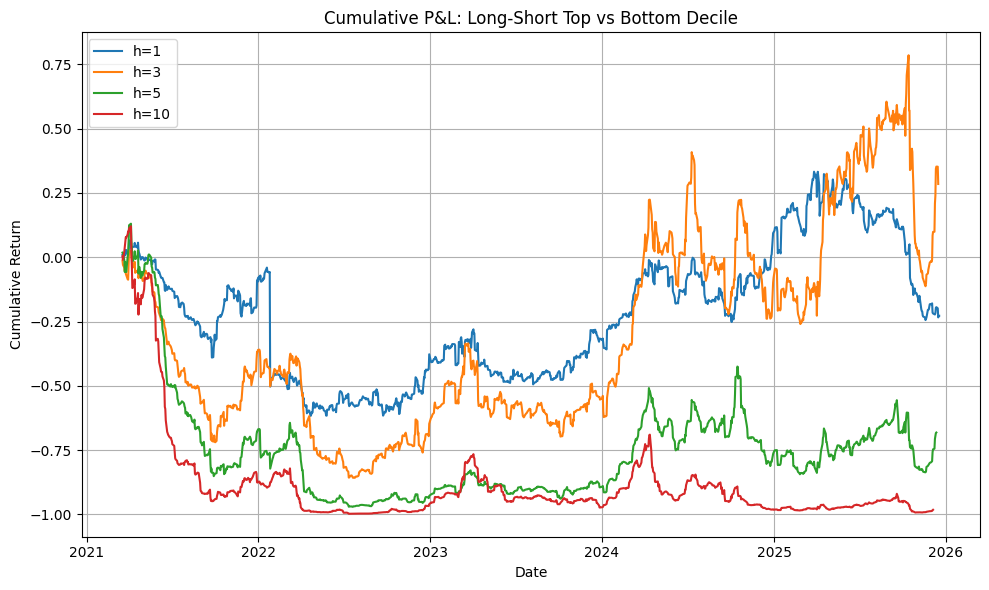


Top decile counts (most frequently in top decile):
ES    711
SI    460
6E    405
6J    398
ZN    235
YM    102
CL     38
NG     38
GC     11
NQ      0
dtype: int64

Bottom decile counts (most frequently in bottom decile):
ZB    592
NG    324
NQ    150
YM     50
CL     27
GC     19
SI     19
ZN     18
6E      0
6J      0
dtype: int64


In [29]:
import pandas as pd
import numpy as np

# Decile portfolio evaluation + multi-horizon P&L / Sharpe calculations
# Relies on notebook variables already present: val_x, val_y, val_predictions, tickers, common_index, split_idx
import matplotlib.pyplot as plt

# ---------------------------
# Helper: normalize prediction tensor/array to (T_val, N) numpy array
# ---------------------------
def preds_to_2d(preds, reference_y):
    # preds: torch.Tensor or np.ndarray of various shapes
    if hasattr(preds, "cpu"):
        arr = preds.cpu().numpy()
    else:
        arr = np.array(preds)
    # drop trailing singleton dims
    arr = np.squeeze(arr)
    # If already 2D with shape (T_val, N) return
    if arr.ndim == 2:
        return arr
    # If shape is (B, T, N) or (B, T, N, 1) etc, flatten leading dims into time axis
    if arr.ndim >= 3:
        # keep last dim as N
        N = arr.shape[-1]
        arr = arr.reshape(-1, N)
        # If we've created more time steps than reference, try to trim or pad
    # Align to reference_y shape if possible
    ref_t = reference_y.shape[0]
    if arr.shape[0] >= ref_t:
        arr = arr[:ref_t, :]
    elif arr.shape[0] < ref_t:
        # pad with last row (safe fallback)
        pad = np.tile(arr[-1:], (ref_t - arr.shape[0], 1))
        arr = np.vstack([arr, pad])
    return arr

# reference actuals for validation
y_val = val_y.cpu().numpy() if hasattr(val_y, "cpu") else np.array(val_y)
y_val = np.squeeze(y_val)  # (T_val, N)

preds_arr = preds_to_2d(val_predictions, y_val)  # (T_val, N)

# validation timestamps
val_dates = np.array(common_index[split_idx:])  # array-like of timestamps matching val_x/val_y

# Build DataFrames
preds_df = pd.DataFrame(preds_arr, index=val_dates, columns=tickers)
actual_log_df = pd.DataFrame(y_val, index=val_dates, columns=tickers)  # log returns

# ---------------------------
# Evaluate decile long-short strategy for multiple holding horizons
# - Use predicted 1-step ahead signal to rank tickers at each date
# - Realized returns for horizon h computed by summing log-returns over h days, then converting to simple returns
# - Strategy = equally-weighted long top decile minus equally-weighted short bottom decile
# ---------------------------
def decile_strategy_returns(preds_df, actual_log_df, horizon=1):
    # realized log return over horizon starting at t: sum_{k=0..h-1} r_{t+k}
    realized_log = actual_log_df.rolling(window=horizon, min_periods=horizon).sum().shift(-horizon + 1)
    realized_simple = np.expm1(realized_log)  # convert log-sum -> simple return

    # Use preds at time t to form portfolio that will earn realized_simple at t (horizon)
    preds = preds_df.loc[realized_simple.index]  # align indexes
    # rank into deciles (percentile rank across tickers)
    ranks = preds.rank(axis=1, method="first", pct=True)
    deciles = (ranks * 10).clip(0, 9).astype(int)  # 0..9 integers

    # compute returns per timestamp
    returns = []
    long_mean_list = []
    short_mean_list = []
    top_mean_list = []
    bot_mean_list = []

    for ts in realized_simple.index:
        row_returns = realized_simple.loc[ts]
        row_dec = deciles.loc[ts]
        if row_dec.isna().any() or row_returns.isna().all():
            returns.append(np.nan)
            long_mean_list.append(np.nan); short_mean_list.append(np.nan)
            top_mean_list.append(np.nan); bot_mean_list.append(np.nan)
            continue
        # mask for top decile (9) and bottom decile (0)
        top_mask = row_dec == 9
        bot_mask = row_dec == 0
        # equal-weighted within each decile
        if top_mask.sum() == 0 or bot_mask.sum() == 0:
            returns.append(np.nan)
            long_mean_list.append(np.nan); short_mean_list.append(np.nan)
            top_mean_list.append(np.nan); bot_mean_list.append(np.nan)
            continue
        top_ret = row_returns[top_mask].mean()
        bot_ret = row_returns[bot_mask].mean()
        long_mean_list.append(top_ret)
        short_mean_list.append(bot_ret)
        # strategy: long top decile, short bottom decile (dollar-neutral)
        strat_ret = top_ret - bot_ret
        returns.append(strat_ret)
        top_mean_list.append(top_ret); bot_mean_list.append(bot_ret)

    strat_series = pd.Series(returns, index=realized_simple.index, name=f"LS_h{horizon}")
    info = pd.DataFrame({
        "long_mean": top_mean_list,
        "short_mean": short_mean_list,
    }, index=realized_simple.index)
    return strat_series.dropna(), info.loc[strat_series.dropna().index]

# metrics
def performance_metrics(returns_series, horizon=1, periods_per_year=252):
    # returns_series are period returns (simple returns for each holding period)
    r = returns_series.dropna().astype(float)
    if r.empty:
        return {}
    # If returns are multi-day (horizon>1), adjust periods_per_year accordingly
    periods = periods_per_year / horizon
    avg = r.mean()
    vol = r.std(ddof=1)
    sharpe = (avg / vol) * np.sqrt(periods) if vol > 0 else np.nan
    # cumulative simple return (chain)
    cum = (1 + r).prod() - 1
    # approximate annualized return and vol
    ann_ret = (1 + cum) ** (periods / len(r)) - 1 if len(r) > 0 else np.nan
    ann_vol = vol * np.sqrt(periods)
    metrics = {
        "n_periods": len(r),
        "mean_period_ret": avg,
        "std_period_ret": vol,
        "sharpe_ann": sharpe,
        "cum_ret": cum,
        "ann_ret_approx": ann_ret,
        "ann_vol_approx": ann_vol
    }
    return metrics

# horizons to evaluate (days)
horizons = [1, 3, 5, 10]
results = {}
for h in horizons:
    strat_ser, info_df = decile_strategy_returns(preds_df, actual_log_df, horizon=h)
    mets = performance_metrics(strat_ser, horizon=h, periods_per_year=252)
    # also compute average long vs short returns stats
    mets["avg_long"] = info_df["long_mean"].mean()
    mets["avg_short"] = info_df["short_mean"].mean()
    results[h] = {"returns": strat_ser, "metrics": mets, "info": info_df}

# ---------------------------
# Report concise summary
# ---------------------------
print("Decile long-short strategy summary (signal = predicted 1-step ahead):")
summary_rows = []
for h in horizons:
    m = results[h]["metrics"]
    summary_rows.append({
        "horizon_days": h,
        "observations": m["n_periods"],
        "mean_period_ret": m["mean_period_ret"],
        "std_period_ret": m["std_period_ret"],
        "ann_sharpe": m["sharpe_ann"],
        "cum_return": m["cum_ret"],
        "ann_return_approx": m["ann_ret_approx"],
        "ann_vol_approx": m["ann_vol_approx"],
        "avg_long": m["avg_long"],
        "avg_short": m["avg_short"],
    })
summary_df = pd.DataFrame(summary_rows).set_index("horizon_days")
print(summary_df.T)

# ---------------------------
# Quick plots: cumulative P&L for each horizon
# ---------------------------
plt.figure(figsize=(10, 6))
for h in horizons:
    s = results[h]["returns"]
    if s.empty:
        continue
    cum = (1 + s).cumprod() - 1
    plt.plot(cum.index, cum.values, label=f"h={h}")
plt.legend()
plt.title("Cumulative P&L: Long-Short Top vs Bottom Decile")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------
# Example: Inspect top/bottom tickers frequency in top decile (signal stability)
# ---------------------------
# compute how often each ticker is chosen to top decile (h=1)
_, info1 = decile_strategy_returns(preds_df, actual_log_df, horizon=1)
# decile mask where preds placed into top decile:
ranks = preds_df.rank(axis=1, method="first", pct=True)
deciles = (ranks * 10).clip(0, 9).astype(int)
top_counts = (deciles == 9).sum(axis=0).sort_values(ascending=False)
bot_counts = (deciles == 0).sum(axis=0).sort_values(ascending=False)

print("\nTop decile counts (most frequently in top decile):")
print(top_counts.head(10))
print("\nBottom decile counts (most frequently in bottom decile):")
print(bot_counts.head(10))

# ---------------------------
# Notes / next actions:
# - If you want multi-step predictive signals (forecast t+3, t+5) you can either:
#   1) roll the model forward autoregressively (feed predictions back into features and rebuild edges),
#   2) train direct multi-horizon heads, or
#   3) use the 1-step model as a signal and evaluate realized multi-day returns (as done above).
# - Consider transaction costs, turnover, and capacity when interpreting Sharpe.
# ---------------------------